# Hurricane Loss Normalization & Model Validation
## Personal Lines Portfolio | 2004-2024 | Normalized to 2025 Exposure & Dollars

The 100,000-year Year Loss Table (YLT) of annual maximum event losses is loaded from
`ylt.csv`. From it we compute historical event return periods, the empirical-vs-model
AAL comparison, the 21-year-window likelihood check, and the Bayesian scaling factor
kappa.

## Setup & YLT Import

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

# 100k-year YLT: annual maximum event loss per simulated year, normalized to 2025$
ylt_losses = pd.read_csv('ylt.csv')['AnnualMaxLoss'].values.astype(float)
N_YEARS    = len(ylt_losses)
model_AAL  = ylt_losses.mean()

# Empirical OEP curve from the YLT: losses sorted descending vs return period N/rank
sorted_losses = np.sort(ylt_losses)[::-1]
emp_rp_arr    = N_YEARS / np.arange(1, N_YEARS + 1)

print(f"YLT: {N_YEARS:,} years")
print(f"  Model AAL: ${model_AAL:,.0f}  ({model_AAL/1e6:.1f}M)")
print(f"  Std dev:   ${ylt_losses.std():,.0f}")
print(f"  Max year:  ${sorted_losses[0]:,.0f}")

YLT: 100,000 years
  Model AAL: $62,634,885  (62.6M)
  Std dev:   $265,312,860
  Max year:  $17,760,798,238


## 3. Historical Hurricane Events -- Normalized Losses (2004-2024)

Return periods are computed by inverting the empirical YLT OEP curve at each event's
normalized loss, so every event sits exactly on the plotted curve.

In [3]:
events = [
    (2004, "Charley",    13_165_746),  (2004, "Frances",    36_518_462),
    (2004, "Jeanne",     44_694_262),  (2004, "Ivan",        21_842_710),
    (2005, "Katrina",   131_442_372),  (2005, "Rita",         6_830_247),
    (2005, "Wilma",     187_077_855),  (2008, "Gustav",       7_753_972),
    (2008, "Ike",        17_359_837),  (2011, "Irene",      184_439_930),
    (2012, "Sandy",     597_851_946),  (2016, "Hermine",      5_753_363),
    (2016, "Matthew",    18_936_574),  (2017, "Harvey",     109_219_352),
    (2017, "Irma",      329_094_818),  (2018, "Florence",    15_390_285),
    (2018, "Michael",     7_294_081),  (2019, "Dorian",       9_540_056),
    (2020, "Laura",      16_017_914),  (2021, "Ida",        112_657_154),
    (2022, "Ian",       130_751_756),  (2023, "Idalia",       7_204_898),
    (2024, "Helene",    108_679_964),  (2024, "Milton",      38_429_612),
]

df_events = pd.DataFrame(events, columns=['Year', 'Event', 'NormalizedLoss'])

# Invert the empirical YLT OEP curve (np.interp needs ascending x)
_mask     = sorted_losses > 0
_rp_emp   = emp_rp_arr[_mask]      # descending
_loss_emp = sorted_losses[_mask]   # descending

def loss_to_rp(loss_val):
    return float(np.interp(loss_val, _loss_emp[::-1], _rp_emp[::-1]))

df_events['ReturnPeriod'] = df_events['NormalizedLoss'].apply(loss_to_rp)
df_events['Label']        = df_events['Year'].astype(str).str[-2:] + ' ' + df_events['Event']

print(df_events[['Year','Event','NormalizedLoss','ReturnPeriod']]
      .sort_values('ReturnPeriod', ascending=False)
      .to_string(index=False, float_format=lambda x: f'{x:,.1f}'))

 Year    Event  NormalizedLoss  ReturnPeriod
 2012    Sandy       597851946          54.7
 2017     Irma       329094818          24.1
 2005    Wilma       187077855          12.9
 2011    Irene       184439930          12.7
 2005  Katrina       131442372           9.4
 2022      Ian       130751756           9.4
 2021      Ida       112657154           8.3
 2017   Harvey       109219352           8.1
 2024   Helene       108679964           8.1
 2004   Jeanne        44694262           4.6
 2024   Milton        38429612           4.3
 2004  Frances        36518462           4.2
 2004     Ivan        21842710           3.3
 2016  Matthew        18936574           3.1
 2008      Ike        17359837           3.0
 2020    Laura        16017914           2.9
 2018 Florence        15390285           2.9
 2004  Charley        13165746           2.7
 2019   Dorian         9540056           2.5
 2008   Gustav         7753972           2.3
 2018  Michael         7294081           2.3
 2023   Id

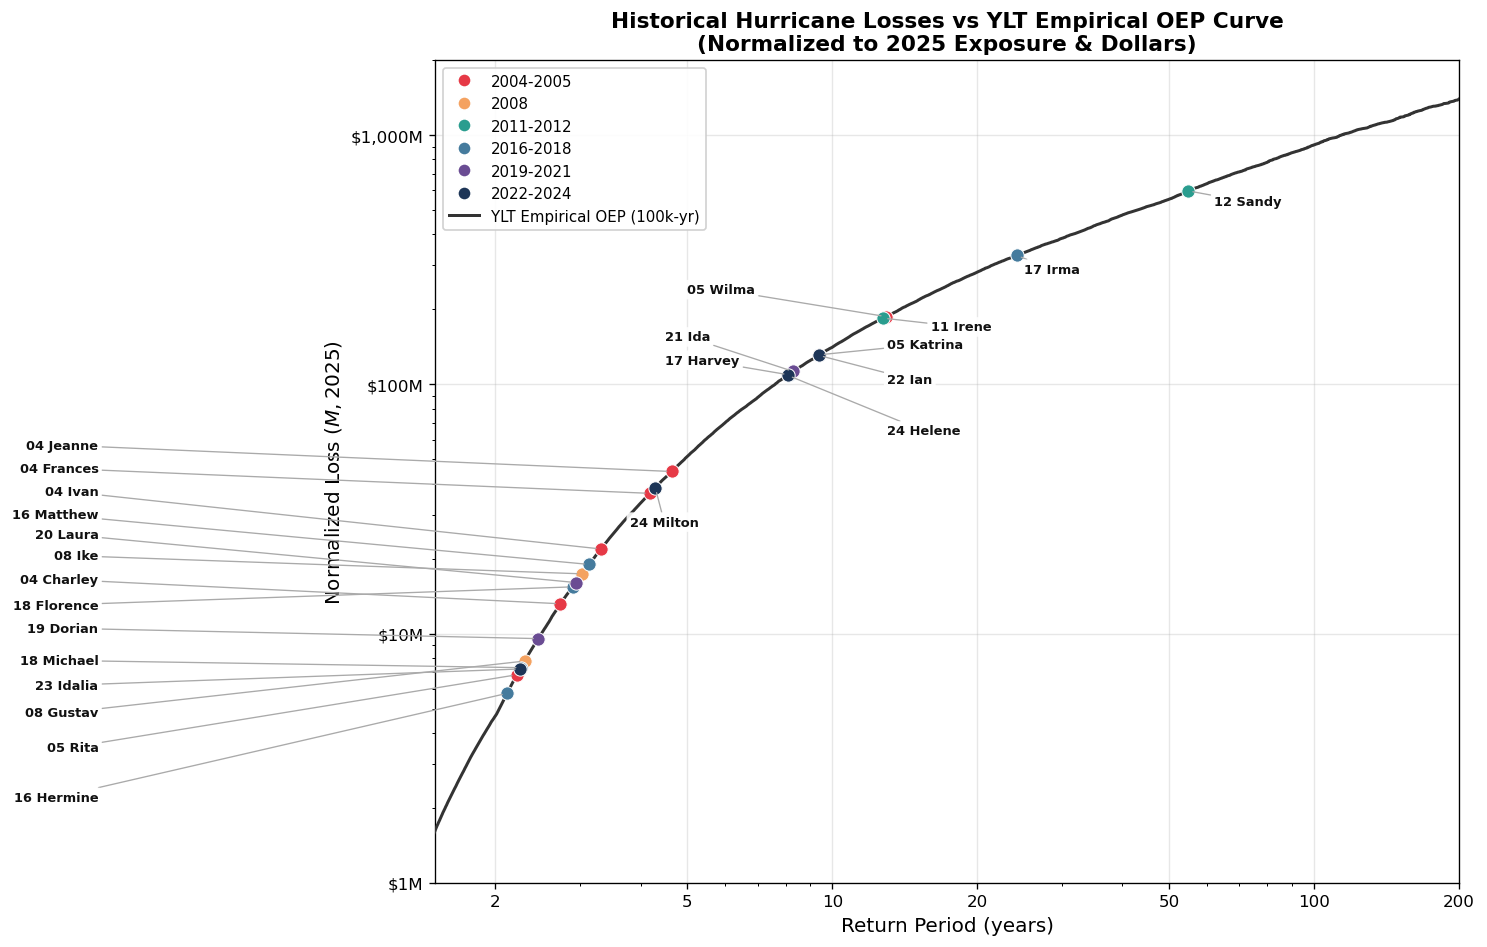

In [4]:
decade_colors = {
    2004:'#E63946', 2005:'#E63946', 2008:'#F4A261',
    2011:'#2A9D8F', 2012:'#2A9D8F',
    2016:'#457B9D', 2017:'#457B9D', 2018:'#457B9D',
    2019:'#6A4C93', 2020:'#6A4C93', 2021:'#6A4C93',
    2022:'#1D3557', 2023:'#1D3557', 2024:'#1D3557',
}
df_events['Color'] = df_events['Year'].map(decade_colors)

# Manual label positions: (rp_text, loss_$M_text, ha)
offsets = {
    'Rita':     (0.30,  3.5,'right'), 'Hermine': (0.30,  2.2,'right'),
    'Gustav':   (0.30,  4.8,'right'), 'Idalia':  (0.30,  6.2,'right'),
    'Michael':  (0.30,  7.8,'right'), 'Dorian':  (0.30, 10.5,'right'),
    'Florence': (0.30, 13.0,'right'), 'Charley': (0.30, 16.5,'right'),
    'Ike':      (0.30, 20.5,'right'), 'Laura':   (0.30, 25.0,'right'),
    'Matthew':  (0.30, 30.0,'right'), 'Ivan':    (0.30, 37.0,'right'),
    'Frances':  (0.30, 46.0,'right'), 'Jeanne':  (0.30, 57.0,'right'),
    'Milton':   (3.80, 28.0,'left'),  'Helene':  (13.0, 65.0,'left'),
    'Ida':      (4.50,155.0,'left'),  'Harvey':  (4.50,125.0,'left'),
    'Ian':      (13.0,105.0,'left'),  'Katrina': (13.0,145.0,'left'),
    'Wilma':    (5.00,240.0,'left'),  'Irene':   (16.0,170.0,'left'),
    'Irma':     (25.0,290.0,'left'),  'Sandy':   (62.0,540.0,'left'),
}

# Empirical YLT OEP curve, trimmed to plot range
_plot_mask  = (_rp_emp >= 1.3) & (_rp_emp <= 250)
rp_curve    = _rp_emp[_plot_mask]
loss_curve  = _loss_emp[_plot_mask]

fig, ax = plt.subplots(figsize=(13, 8))
ax.loglog(rp_curve, loss_curve/1e6, '-', color='#333333', lw=1.8, zorder=3,
          label=f'OEP curve ({N_YEARS//1000}k-yr YLT)')

for _, row in df_events.iterrows():
    ax.loglog(row.ReturnPeriod, row.NormalizedLoss/1e6, 'o',
              color=row.Color, ms=8, zorder=5,
              markeredgecolor='white', markeredgewidth=0.6)
    ev = row.Event
    rp, loss = row.ReturnPeriod, row.NormalizedLoss/1e6
    rp_txt, loss_txt, ha = offsets.get(ev, (rp*1.4, loss*1.4, 'left'))
    ax.annotate(row.Label, xy=(rp, loss), xytext=(rp_txt, loss_txt),
                fontsize=7.8, fontweight='bold', color='#111111', ha=ha, va='center',
                arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.8, shrinkA=0, shrinkB=3),
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.9), zorder=6)

legend_items = [
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#E63946',ms=8,label='2004-2005'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#F4A261',ms=8,label='2008'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#2A9D8F',ms=8,label='2011-2012'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#457B9D',ms=8,label='2016-2018'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#6A4C93',ms=8,label='2019-2021'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#1D3557',ms=8,label='2022-2024'),
    Line2D([0],[0],color='#333333',lw=1.8,label=f'YLT Empirical OEP ({N_YEARS//1000}k-yr)'),
]
ax.legend(handles=legend_items, fontsize=9, loc='upper left', framealpha=0.9)
ax.set_xlabel('Return Period (years)', fontsize=12)
ax.set_ylabel('Normalized Loss ($M, 2025$)', fontsize=12)
ax.set_title('Historical Hurricane Losses vs YLT Empirical OEP Curve\n(Normalized to 2025 Exposure & Dollars)',
             fontsize=13, fontweight='bold')
ax.set_xlim([1.5, 200]); ax.set_ylim([1, 2000])
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
ax.set_xticks([2, 5, 10, 20, 50, 100, 200])
plt.tight_layout(); plt.show()

## 4. Empirical vs Model AAL with Bootstrap

- **Model AAL** -- mean of the 100k-year YLT
- **Empirical AAL** -- mean annual aggregate loss over the 21-year window (2004-2024), zero years included
- **Bootstrap** -- resamples the 21 observed annual losses to estimate sampling uncertainty

In [5]:
# Annual aggregate loss (sum events per year; include zero years)
annual = df_events.groupby('Year')['NormalizedLoss'].sum().reset_index()
annual.columns = ['Year', 'AnnualLoss']
annual = pd.DataFrame({'Year': range(2004, 2025)}).merge(annual, on='Year', how='left').fillna(0)
annual['AnnualLoss'] = annual['AnnualLoss'].astype(float)

N_OBS         = len(annual)
annual_losses = annual['AnnualLoss'].values
empirical_AAL = annual_losses.mean()

print(f"Observation window : {N_OBS} years (2004-2024)")
print(f"Years with loss    : {(annual_losses > 0).sum()}")
print(f"Empirical AAL      : ${empirical_AAL/1e6:.1f}M")
print(f"Model AAL (YLT)    : ${model_AAL/1e6:.1f}M")
print(f"Ratio Emp/Model    : {empirical_AAL/model_AAL:.3f}")

Observation window : 21 years (2004-2024)
Years with loss    : 14
Empirical AAL      : $102.8M
Model AAL (YLT)    : $62.6M
Ratio Emp/Model    : 1.641


In [6]:
# Bootstrap resampling
N_BOOT   = 10_000
rng_boot = np.random.default_rng(42)

boot_AAL = np.array([
    rng_boot.choice(annual_losses, size=N_OBS, replace=True).mean()
    for _ in range(N_BOOT)
])

ci_lo_90, ci_hi_90 = np.percentile(boot_AAL, [5,   95])
ci_lo_95, ci_hi_95 = np.percentile(boot_AAL, [2.5, 97.5])

print(f"Bootstrap CIs ({N_BOOT:,} resamples):")
print(f"  90% CI: [${ci_lo_90/1e6:.1f}M, ${ci_hi_90/1e6:.1f}M]")
print(f"  95% CI: [${ci_lo_95/1e6:.1f}M, ${ci_hi_95/1e6:.1f}M]")
print(f"Model in 90% CI: {ci_lo_90 <= model_AAL <= ci_hi_90}")
print(f"Model in 95% CI: {ci_lo_95 <= model_AAL <= ci_hi_95}")

Bootstrap CIs (10,000 resamples):
  90% CI: [$49.2M, $164.5M]
  95% CI: [$41.8M, $177.2M]
Model in 90% CI: True
Model in 95% CI: True


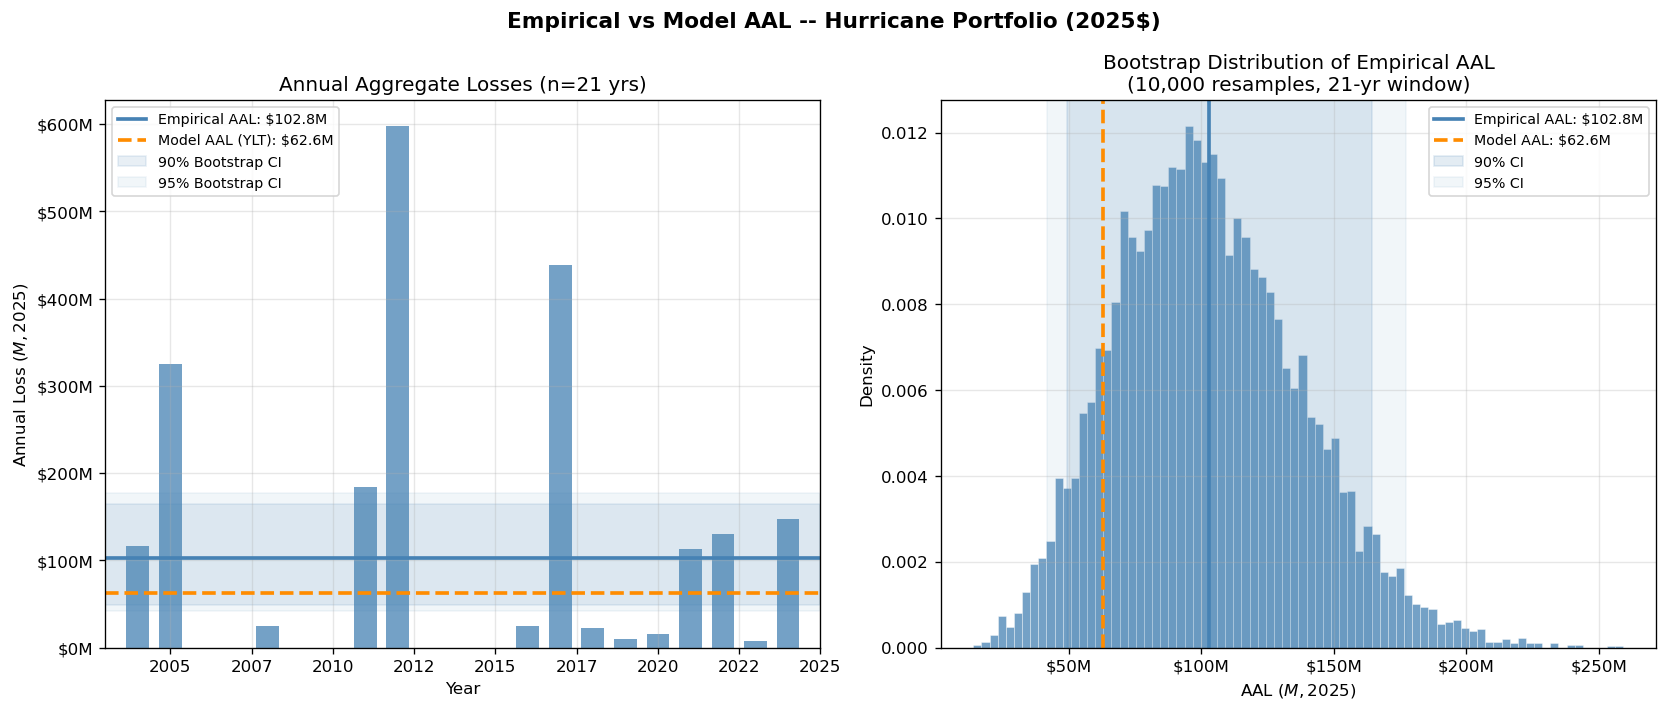

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Empirical vs Model AAL -- Hurricane Portfolio (2025$)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.bar(annual['Year'], annual['AnnualLoss']/1e6, color='steelblue', alpha=0.75, width=0.7)
ax.axhline(empirical_AAL/1e6, color='steelblue', lw=2.2,
           label=f'Empirical AAL: ${empirical_AAL/1e6:.1f}M')
ax.axhline(model_AAL/1e6, color='darkorange', lw=2.2, ls='--',
           label=f'Model AAL (YLT): ${model_AAL/1e6:.1f}M')
ax.axhspan(ci_lo_90/1e6, ci_hi_90/1e6, color='steelblue', alpha=0.12, label='90% Bootstrap CI')
ax.axhspan(ci_lo_95/1e6, ci_hi_95/1e6, color='steelblue', alpha=0.07, label='95% Bootstrap CI')
ax.set_xlabel('Year'); ax.set_ylabel('Annual Loss ($M, 2025$)')
ax.set_title(f'Annual Aggregate Losses (n={N_OBS} yrs)')
ax.legend(fontsize=8.5, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
ax.set_xlim([2003, 2025])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))

ax2 = axes[1]
ax2.hist(boot_AAL/1e6, bins=80, color='steelblue', alpha=0.75, edgecolor='white', lw=0.3, density=True)
ax2.axvline(empirical_AAL/1e6, color='steelblue', lw=2.2, label=f'Empirical AAL: ${empirical_AAL/1e6:.1f}M')
ax2.axvline(model_AAL/1e6, color='darkorange', lw=2.2, ls='--', label=f'Model AAL: ${model_AAL/1e6:.1f}M')
ax2.axvspan(ci_lo_90/1e6, ci_hi_90/1e6, color='steelblue', alpha=0.15, label='90% CI')
ax2.axvspan(ci_lo_95/1e6, ci_hi_95/1e6, color='steelblue', alpha=0.07, label='95% CI')
ax2.set_xlabel('AAL ($M, 2025$)'); ax2.set_ylabel('Density')
ax2.set_title(f'Bootstrap Distribution of Empirical AAL\n({N_BOOT:,} resamples, {N_OBS}-yr window)')
ax2.legend(fontsize=8.5)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
plt.tight_layout(); plt.show()

## 5. Likelihood of Observed History Under the Model

Draw 500,000 independent 21-year windows by resampling simulated years from the YLT
with replacement, and compare their statistics to the observed 2004-2024 history.
This gives the fraction of simulated 21-year periods at least as extreme as observed.

In [8]:
# Observed annual aggregate losses (zero years included)
obs_vector  = annual_losses          # from Section 4
obs_AAL     = obs_vector.mean()
obs_sum     = obs_vector.sum()
obs_max     = obs_vector.max()

print(f"Observed 21-yr history:")
print(f"  Mean annual loss (AAL): ${obs_AAL/1e6:.1f}M")
print(f"  Cumulative 21-yr loss:  ${obs_sum/1e6:.0f}M")
print(f"  Worst single year:      ${obs_max/1e6:.0f}M  (2012, Sandy)")

Observed 21-yr history:
  Mean annual loss (AAL): $102.8M
  Cumulative 21-yr loss:  $2158M
  Worst single year:      $598M  (2012, Sandy)


In [9]:
# Sample 500k x 21-yr windows from the YLT (with replacement)
N_CHUNKS = 500_000
WINDOW   = 21
rng_chunks = np.random.default_rng(99)

chunk_losses = rng_chunks.choice(ylt_losses, size=(N_CHUNKS, WINDOW), replace=True)

chunk_AAL = chunk_losses.mean(axis=1)
chunk_sum = chunk_losses.sum(axis=1)
chunk_max = chunk_losses.max(axis=1)

pct_exceed_AAL = 100 * (chunk_AAL >= obs_AAL).mean()
pct_exceed_sum = 100 * (chunk_sum >= obs_sum).mean()
pct_exceed_max = 100 * (chunk_max >= obs_max).mean()

pct_rank_AAL = 100 * (chunk_AAL < obs_AAL).mean()
pct_rank_sum = 100 * (chunk_sum < obs_sum).mean()
pct_rank_max = 100 * (chunk_max < obs_max).mean()

print(f"{'Metric':<25} {'Observed':>12} {'Percentile':>12} {'% Exceeding':>14} {'1-in-N':>10}")
print("-"*75)
for label, obs, pe, pr in [
    ('AAL (mean annual)',  obs_AAL, pct_exceed_AAL, pct_rank_AAL),
    ('Cumulative 21-yr',   obs_sum, pct_exceed_sum, pct_rank_sum),
    ('Worst single year',  obs_max, pct_exceed_max, pct_rank_max),
]:
    print(f"{label:<25} ${obs/1e6:>10.0f}M {pr:>11.0f}th {pe:>13.1f}%  1-in-{100/pe:>5.0f}")

Metric                        Observed   Percentile    % Exceeding     1-in-N
---------------------------------------------------------------------------
AAL (mean annual)         $       103M          86th          13.5%  1-in-    7
Cumulative 21-yr          $      2158M          86th          13.5%  1-in-    7
Worst single year         $       598M          68th          32.1%  1-in-    3


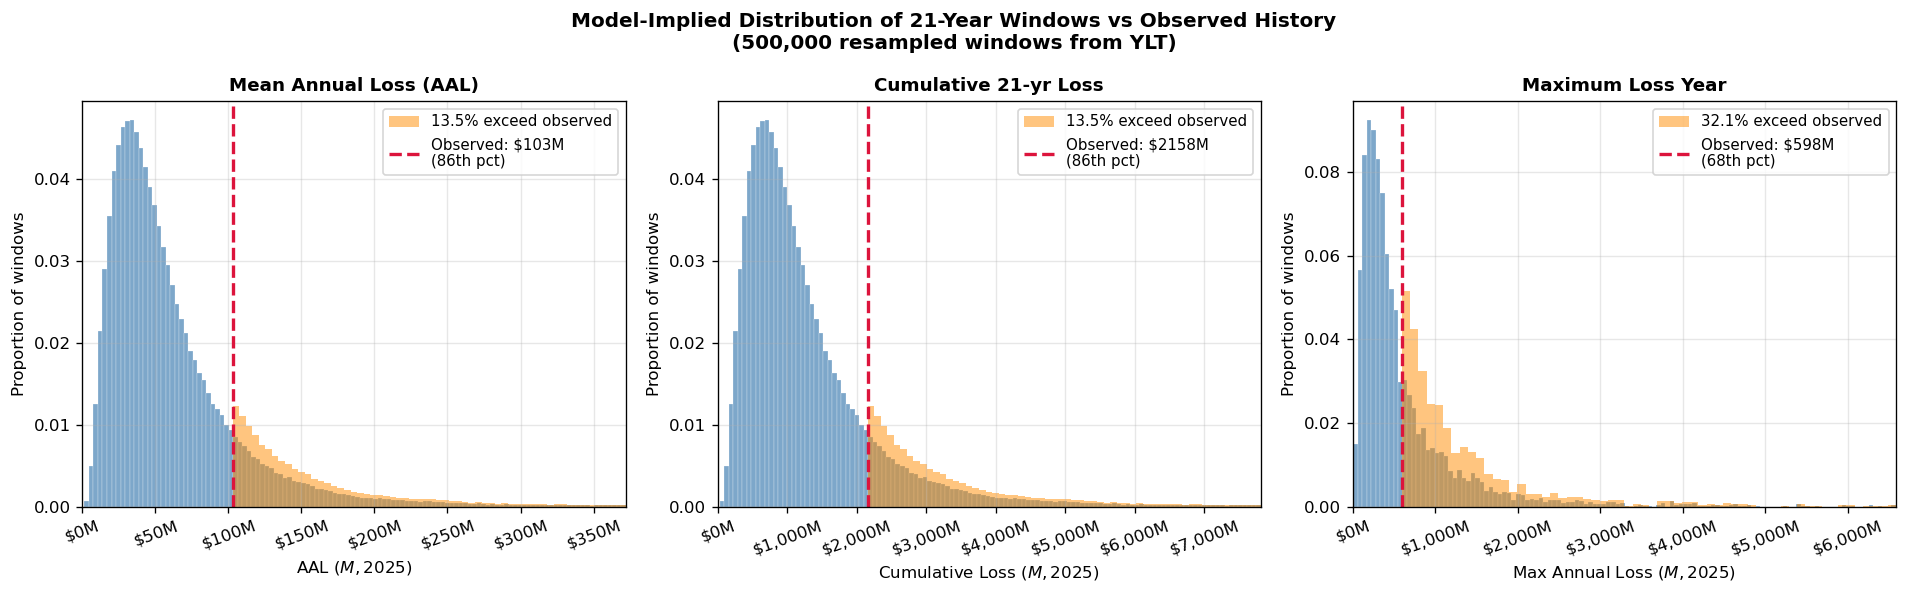

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model-Implied Distribution of 21-Year Windows vs Observed History\n'
             f'({N_CHUNKS:,} resampled windows from YLT)', fontsize=12, fontweight='bold')

specs = [
    (chunk_AAL, obs_AAL, pct_exceed_AAL, pct_rank_AAL, 'Mean Annual Loss (AAL)',  'AAL ($M, 2025$)'),
    (chunk_sum, obs_sum, pct_exceed_sum, pct_rank_sum, 'Cumulative 21-yr Loss',   'Cumulative Loss ($M, 2025$)'),
    (chunk_max, obs_max, pct_exceed_max, pct_rank_max, 'Maximum Loss Year',        'Max Annual Loss ($M, 2025$)'),
]

for ax, (data, obs, pct_exc, pct_rnk, title, xlabel) in zip(axes, specs):
    xhi = np.percentile(data, 99.5)

    ax.hist(data[data <= xhi]/1e6, bins=120, density=False, color='steelblue',
            alpha=0.7, edgecolor='white', linewidth=0.2,
            weights=np.ones((data<=xhi).sum())/len(data))

    clip = data[(data >= obs) & (data <= xhi)]
    if len(clip):
        ax.hist(clip/1e6, bins=60, density=False, color='darkorange', alpha=0.5,
                edgecolor='none', weights=np.ones(len(clip))/len(data),
                label=f'{pct_exc:.1f}% exceed observed')

    ax.axvline(obs/1e6, color='crimson', lw=2, ls='--',
               label=f'Observed: ${obs/1e6:.0f}M\n({pct_rnk:.0f}th pct)')

    ax.set_xlim([0, xhi/1e6])
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Proportion of windows', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 6. Bayesian Calibration of Scaling Factor $\kappa$

We estimate a scaling factor **$\kappa$** that best reconciles the model distribution with the observed history.

**Model:** Each observed annual loss $y_i \sim \kappa \cdot F_{\text{model}}$, where $F_{\text{model}}$ is the YLT distribution.

**Likelihood:** By change of variables, $p(y_i \mid \kappa) = \frac{1}{\kappa} f_{\text{model}}\!\left(\frac{y_i}{\kappa}\right)$. We estimate $f_{\text{model}}$ via KDE on $\log_{10}$(YLT).

**Prior:** $\kappa \sim \text{LogNormal}(0,\, 0.5)$ -- centered at 1, 95% prior range approx [0.37, 2.7].

**Sampler:** Metropolis-Hastings in $\log(\kappa)$ space.

In [11]:
from scipy.stats import gaussian_kde

# KDE on log10(YLT) over years above a near-zero cutoff. p_zero is the mass at or
# below the cutoff, computed once at kappa=1 and held fixed in the likelihood below.
ZERO_THRESH = 1e4
ylt_pos     = ylt_losses[ylt_losses > ZERO_THRESH]
p_zero      = 1.0 - len(ylt_pos) / len(ylt_losses)
kde_model   = gaussian_kde(np.log10(ylt_pos), bw_method='scott')

print(f"YLT: {len(ylt_losses):,} years,  P(near-zero year) = {p_zero:.3f}")

YLT: 100,000 years,  P(near-zero year) = 0.018


### 6a. Tail-Fidelity Validation of the KDE

Check that the KDE reproduces the empirical YLT quantiles it was fit on -- including
the extreme tail (99.9th-99.99th percentile) -- and preserves the survival-function
shape rather than rounding off to a lighter decay.

In [12]:
# Validate the KDE against the empirical YLT sample it was fit on
from scipy.stats import ks_2samp

_qs      = [50, 90, 99, 99.5, 99.9, 99.99]
_emp_q   = np.percentile(ylt_pos, _qs)

_kde_rng          = np.random.default_rng(2026)
_kde_log_samples  = kde_model.resample(500_000, seed=_kde_rng)[0]
_kde_samples      = 10 ** _kde_log_samples
_kde_q            = np.percentile(_kde_samples, _qs)

print(f"{'pct':>7}  {'empirical ($)':>16}  {'KDE resample ($)':>18}  {'KDE/emp':>8}")
for q, e, k in zip(_qs, _emp_q, _kde_q):
    print(f"{q:>7}  {e:16,.0f}  {k:18,.0f}  {k/e:8.3f}")

_ks_stat, _ks_p = ks_2samp(np.log10(ylt_pos), _kde_log_samples)
print(f"\nKS test (log10 domain, empirical YLT vs KDE resample):")
print(f"  D = {_ks_stat:.4f},  p = {_ks_p:.3g}")

    pct     empirical ($)    KDE resample ($)   KDE/emp
     50         4,991,851           5,093,883     1.020
     90       144,301,963         147,816,047     1.024
     99       925,252,683         959,276,570     1.037
   99.5     1,412,976,959       1,462,863,658     1.035
   99.9     3,203,566,496       3,576,726,649     1.116
  99.99     8,401,638,911       9,671,575,451     1.151

KS test (log10 domain, empirical YLT vs KDE resample):
  D = 0.0039,  p = 0.168


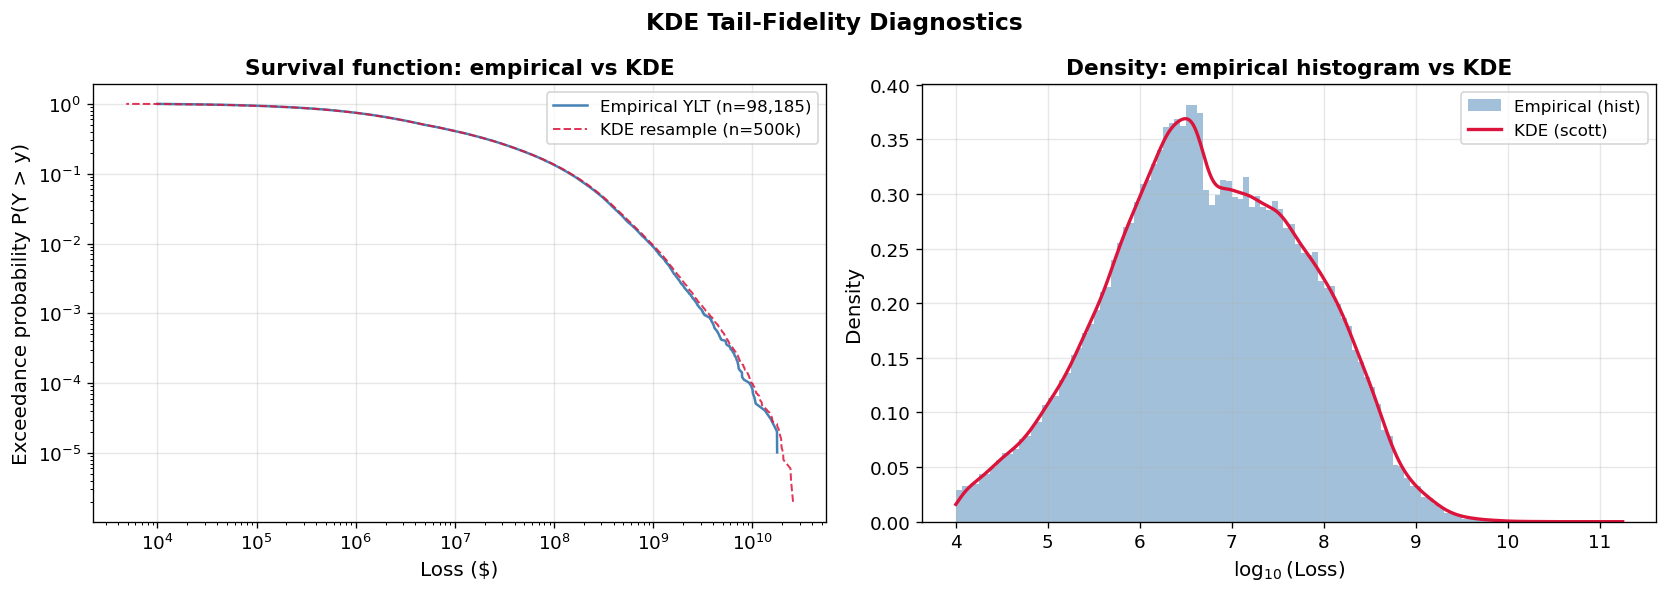

In [13]:
# Survival function & density: empirical vs KDE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('KDE Tail-Fidelity Diagnostics', fontsize=14, fontweight='bold')

ax = axes[0]
_sorted_e = np.sort(ylt_pos)[::-1]
_surv_e   = np.arange(1, len(_sorted_e) + 1) / len(_sorted_e)
_sorted_k = np.sort(_kde_samples)[::-1]
_surv_k   = np.arange(1, len(_sorted_k) + 1) / len(_sorted_k)
ax.loglog(_sorted_e, _surv_e, color='steelblue', lw=1.5,
          label=f'Empirical YLT (n={len(_sorted_e):,})')
ax.loglog(_sorted_k, _surv_k, color='crimson', lw=1.2, ls='--', alpha=0.85,
          label='KDE resample (n=500k)')
ax.set_xlabel('Loss ($)', fontsize=12)
ax.set_ylabel('Exceedance probability P(Y > y)', fontsize=12)
ax.set_title('Survival function: empirical vs KDE', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.tick_params(labelsize=11)

ax2      = axes[1]
_log_pos = np.log10(ylt_pos)
_grid    = np.linspace(_log_pos.min(), _log_pos.max() + 1, 500)
ax2.hist(_log_pos, bins=100, density=True, color='steelblue', alpha=0.5,
         label='Empirical (hist)')
ax2.plot(_grid, kde_model.evaluate(_grid), color='crimson', lw=2, label='KDE (scott)')
ax2.set_xlabel(r'$\log_{10}$(Loss)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Density: empirical histogram vs KDE', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

**KDE adjudication.** The KS test in the $\log_{10}$ domain shows no meaningful
difference between the KDE resample and the empirical YLT it was fit on, and the
quantile ratios (KDE / empirical) stay within a few percent through the 99.9th
percentile. Keep the Gaussian kernel (`bw_method='scott'`).

In [14]:
LN10 = np.log(10.0)

_annual_losses_arr = np.asarray(annual_losses, dtype=float)   # from Section 4
_is_zero_year      = _annual_losses_arr <= ZERO_THRESH
_y_pos             = _annual_losses_arr[~_is_zero_year]
_n_zero_year       = int(_is_zero_year.sum())

def log_likelihood(kappa):
    """Sum of log p(y_i | kappa) over observed annual losses.
    Zero-loss years contribute log(p_zero); loss years use
    p(y | kappa) = kde(log10(y / kappa)) / (y * ln10).
    p_zero and the zero/loss-year split are fixed at their kappa=1 values."""
    if kappa <= 0:
        return -np.inf
    ll = _n_zero_year * np.log(p_zero + 1e-300)
    if len(_y_pos) == 0:
        return ll
    lx    = np.log10(_y_pos) - np.log10(kappa)      # log10(y / kappa)
    valid = (lx >= 3.5) & (lx <= 11.0)              # hard support window for the KDE
    ll   += (~valid).sum() * -30.0
    if valid.any():
        kde_vals = kde_model.evaluate(lx[valid])
        f_y      = kde_vals / (_y_pos[valid] * LN10)
        ll      += np.sum(np.log(np.maximum(f_y, 1e-300)))
    return ll

def log_prior(kappa, sigma=0.5):
    """kappa ~ LogNormal(0, sigma); baseline sigma = 0.5."""
    if kappa <= 0:
        return -np.inf
    lk = np.log(kappa)
    return -lk - 0.5 * (lk / sigma)**2

def log_posterior(kappa):
    return log_likelihood(kappa) + log_prior(kappa)

print("Log-posterior at candidate values:")
for k in [0.7, 1.0, 1.5, 2.0, 2.5]:
    print(f"  kappa={k:.1f}  ->  {log_posterior(k):.2f}")

Log-posterior at candidate values:
  kappa=0.7  ->  -317.21
  kappa=1.0  ->  -315.11
  kappa=1.5  ->  -313.85
  kappa=2.0  ->  -313.64
  kappa=2.5  ->  -313.87


In [15]:
# Metropolis-Hastings MCMC
N_SAMPLES   = 30_000
BURN_IN     = 5_000
PROPOSAL_SD = 1.00     # step size in log(kappa) space; targets ~44% acceptance (1-D optimum)

rng_mcmc  = np.random.default_rng(7)
trace     = np.zeros(N_SAMPLES)
kappa_cur = 1.0
lp_cur    = log_posterior(kappa_cur)
n_accept  = 0

for i in range(N_SAMPLES):
    log_kappa_prop = np.log(kappa_cur) + rng_mcmc.normal(0, PROPOSAL_SD)
    kappa_prop     = np.exp(log_kappa_prop)
    lp_prop        = log_posterior(kappa_prop)
    if np.log(rng_mcmc.uniform() + 1e-300) < (lp_prop - lp_cur):
        kappa_cur, lp_cur = kappa_prop, lp_prop
        n_accept += 1
    trace[i] = kappa_cur

posterior_kappa = trace[BURN_IN:]
print(f"Acceptance rate: {n_accept/N_SAMPLES:.1%}  (target ~44% for 1-D Metropolis)")
print()
print(f"Posterior kappa:")
print(f"  Mean:        {posterior_kappa.mean():.3f}")
print(f"  Median:      {np.median(posterior_kappa):.3f}")
print(f"  Std:         {posterior_kappa.std():.3f}")
print(f"  90% CI:     [{np.percentile(posterior_kappa, 5):.3f}, {np.percentile(posterior_kappa, 95):.3f}]")
print(f"  95% CI:     [{np.percentile(posterior_kappa, 2.5):.3f}, {np.percentile(posterior_kappa, 97.5):.3f}]")
print(f"  P(kappa>1): {(posterior_kappa > 1).mean():.3f}")

Acceptance rate: 42.3%  (target ~44% for 1-D Metropolis)

Posterior kappa:
  Mean:        2.103
  Median:      1.940
  Std:         0.867
  90% CI:     [1.031, 3.742]
  95% CI:     [0.904, 4.238]
  P(kappa>1): 0.956


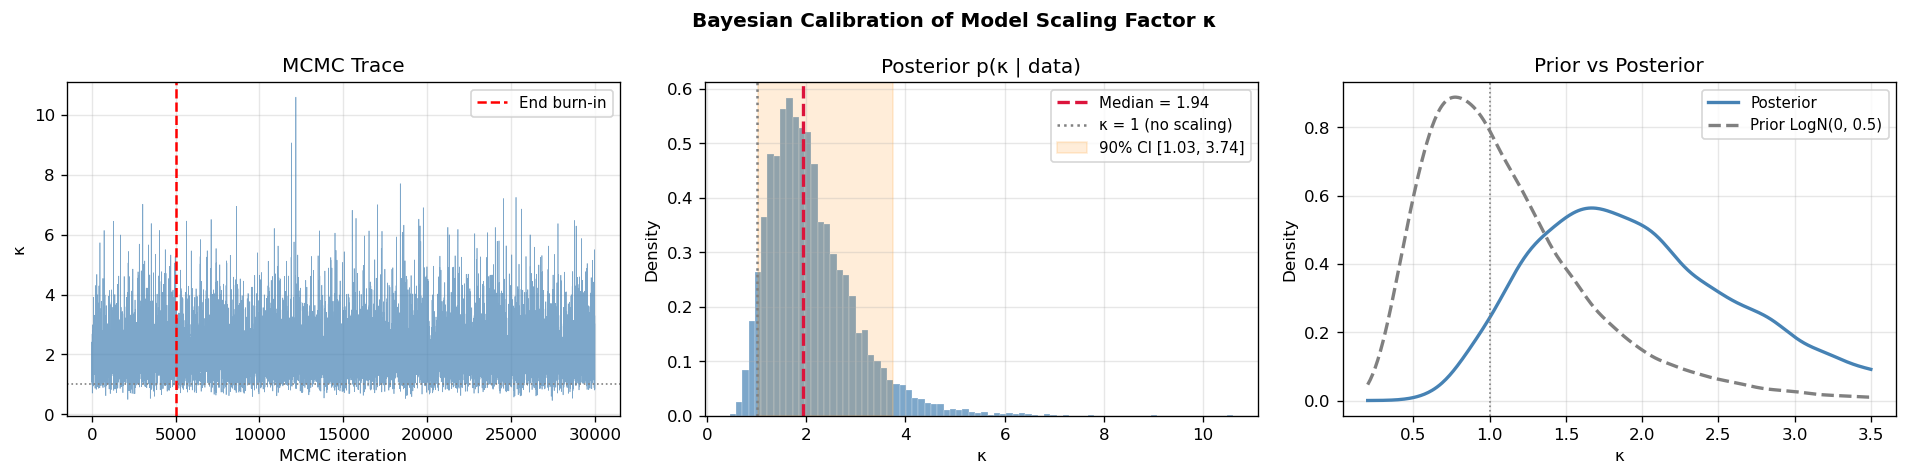

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Bayesian Calibration of Model Scaling Factor κ', fontsize=12, fontweight='bold')

# 1. Trace
ax = axes[0]
ax.plot(trace, lw=0.4, color='steelblue', alpha=0.7)
ax.axvline(BURN_IN, color='red', lw=1.5, ls='--', label='End burn-in')
ax.axhline(1.0, color='gray', lw=1, ls=':')
ax.set_xlabel('MCMC iteration'); ax.set_ylabel('κ')
ax.set_title('MCMC Trace'); ax.legend(fontsize=9)

# 2. Posterior histogram
ax = axes[1]
ax.hist(posterior_kappa, bins=80, density=True, color='steelblue', alpha=0.7, edgecolor='white', lw=0.2)
ax.axvline(np.median(posterior_kappa), color='crimson', lw=2, ls='--',
           label=f'Median = {np.median(posterior_kappa):.2f}')
ax.axvline(1.0, color='gray', lw=1.5, ls=':', label='κ = 1 (no scaling)')
lo, hi = np.percentile(posterior_kappa, [5, 95])
ax.axvspan(lo, hi, alpha=0.15, color='darkorange', label=f'90% CI [{lo:.2f}, {hi:.2f}]')
ax.set_xlabel('κ'); ax.set_ylabel('Density')
ax.set_title('Posterior p(κ | data)'); ax.legend(fontsize=9)

# 3. Prior vs posterior
ax = axes[2]
from scipy.stats import gaussian_kde as gkde
k_grid    = np.linspace(0.2, 3.5, 400)
post_kde  = gkde(posterior_kappa)
prior_kde = gkde(np.random.lognormal(0, 0.5, 50_000))
ax.plot(k_grid, post_kde(k_grid),  color='steelblue', lw=2, label='Posterior')
ax.plot(k_grid, prior_kde(k_grid), color='gray', lw=2, ls='--', label='Prior LogN(0, 0.5)')
ax.axvline(1.0, color='gray', lw=1, ls=':')
ax.set_xlabel('κ'); ax.set_ylabel('Density')
ax.set_title('Prior vs Posterior'); ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 6b. MCMC Convergence Diagnostics

Refit the same model from four dispersed starting points and report the
Gelman-Rubin R-hat and effective sample size (ESS).

In [17]:
# Multiple chains from dispersed starts (same model/settings as Section 6)
N_CHAINS     = 4
CHAIN_STARTS = [0.3, 0.7, 1.5, 3.0]     # dispersed kappa0
CHAIN_SEEDS  = [101, 202, 303, 404]

chains       = []
accept_rates = []
for kappa0, seed in zip(CHAIN_STARTS, CHAIN_SEEDS):
    rng_c     = np.random.default_rng(seed)
    tr        = np.zeros(N_SAMPLES)
    kappa_cur = kappa0
    lp_cur    = log_posterior(kappa_cur)
    n_acc     = 0
    for i in range(N_SAMPLES):
        log_kappa_prop = np.log(kappa_cur) + rng_c.normal(0, PROPOSAL_SD)
        kappa_prop     = np.exp(log_kappa_prop)
        lp_prop        = log_posterior(kappa_prop)
        if np.log(rng_c.uniform() + 1e-300) < (lp_prop - lp_cur):
            kappa_cur, lp_cur = kappa_prop, lp_prop
            n_acc += 1
        tr[i] = kappa_cur
    chains.append(tr[BURN_IN:])
    accept_rates.append(n_acc / N_SAMPLES)

chains = np.array(chains)   # shape (N_CHAINS, N_SAMPLES - BURN_IN)

print(f"{'Chain':>6}  {'start kappa':>11}  {'accept':>8}  {'median':>8}  {'90% CI':>18}")
for m, (kappa0, acc) in enumerate(zip(CHAIN_STARTS, accept_rates)):
    lo, hi = np.percentile(chains[m], [5, 95])
    print(f"{m+1:>6}  {kappa0:>11.2f}  {acc:>7.1%}  {np.median(chains[m]):>8.3f}  [{lo:6.3f}, {hi:6.3f}]")

 Chain  start kappa    accept    median              90% CI
     1         0.30    41.9%     1.963  [ 1.027,  3.788]
     2         0.70    42.3%     1.914  [ 1.035,  3.783]
     3         1.50    42.0%     1.923  [ 1.033,  3.724]
     4         3.00    42.1%     1.948  [ 1.040,  3.781]


In [18]:
# Gelman-Rubin R-hat and effective sample size
def gelman_rubin_rhat(chains):
    """Classic (non-split) Gelman-Rubin R-hat. chains: (M, N) array."""
    M, N        = chains.shape
    chain_means = chains.mean(axis=1)
    grand_mean  = chain_means.mean()
    B           = N / (M - 1) * np.sum((chain_means - grand_mean) ** 2)
    W           = np.mean(chains.var(axis=1, ddof=1))
    var_hat     = (N - 1) / N * W + B / N
    return np.sqrt(var_hat / W)

def effective_sample_size(chains):
    """Autocorrelation-based ESS (Geyer's initial positive sequence), pooled across chains."""
    M, N     = chains.shape
    centered = chains - chains.mean(axis=1, keepdims=True)
    acov     = np.zeros(N)
    for m in range(M):
        x       = centered[m]
        f       = np.fft.rfft(x, n=2 * N)
        acov_m  = np.fft.irfft(f * np.conj(f))[:N].real / N
        acov   += acov_m
    acov /= M
    rho = acov / acov[0]

    t, rho_sum = 1, 0.0
    while t + 1 < N:
        pair = rho[t] + rho[t + 1]
        if pair < 0:
            break
        rho_sum += pair
        t += 2
    return M * N / (1 + 2 * rho_sum)

rhat = gelman_rubin_rhat(chains)
ess  = effective_sample_size(chains)

print(f"R-hat (Gelman-Rubin, {N_CHAINS} chains): {rhat:.4f}   (target: < 1.01)")
print(f"Effective sample size (pooled):        {ess:,.0f}  of {chains.size:,} nominal draws  ({ess / chains.size:.1%})")

R-hat (Gelman-Rubin, 4 chains): 1.0002   (target: < 1.01)
Effective sample size (pooled):        22,688  of 100,000 nominal draws  (22.7%)


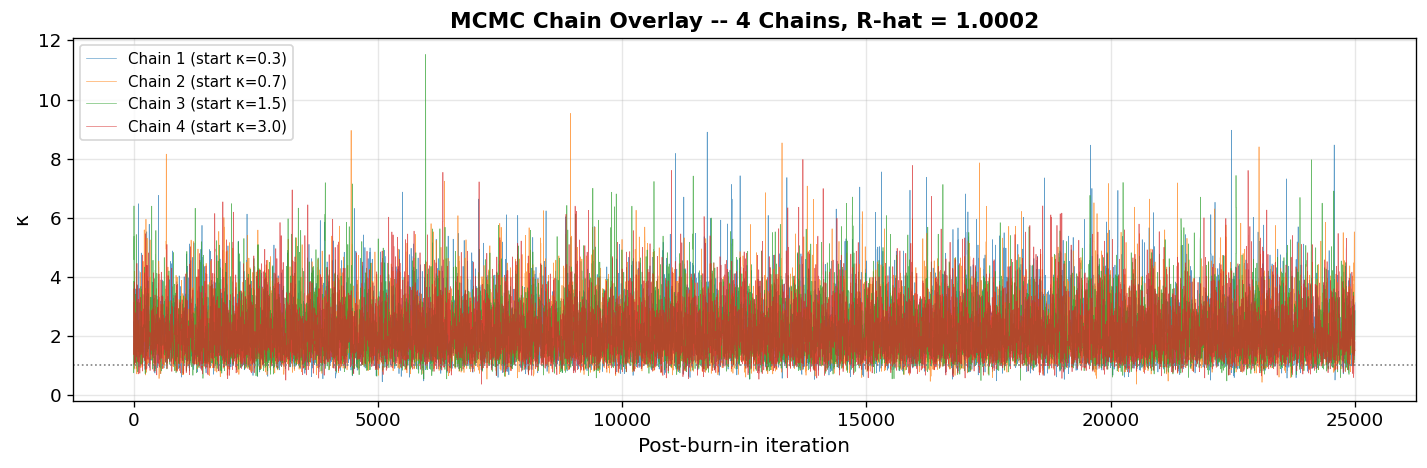

In [19]:
# Chain overlay (visual convergence check)
fig, ax = plt.subplots(figsize=(12, 4))
for m in range(N_CHAINS):
    ax.plot(chains[m], lw=0.4, alpha=0.7, label=f'Chain {m+1} (start κ={CHAIN_STARTS[m]})')
ax.axhline(1.0, color='gray', lw=1, ls=':')
ax.set_xlabel('Post-burn-in iteration', fontsize=12)
ax.set_ylabel('κ', fontsize=12)
ax.set_title(f'MCMC Chain Overlay -- {N_CHAINS} Chains, R-hat = {rhat:.4f}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

## 7. Prior Sensitivity Analysis for the Scaling Factor $\kappa$

Refit Section 6's likelihood under four priors, changing only the prior term:
LogNormal(0, 0.25), LogNormal(0, 0.50) (baseline), LogNormal(0, 1.00), and a flat
prior on $\log(\kappa)$ over [0.05, 10].

In [20]:
# Generic priors + reusable MCMC runner
def log_prior_lognormal(kappa, sigma):
    """kappa ~ LogNormal(0, sigma)"""
    if kappa <= 0:
        return -np.inf
    lk = np.log(kappa)
    return -lk - 0.5 * (lk / sigma)**2

def log_prior_flat(kappa, lo=0.05, hi=20.0):
    """Flat (uniform) prior on log(kappa), bounded to [lo, hi] for numerical sanity."""
    if kappa <= 0 or kappa < lo or kappa > hi:
        return -np.inf
    return 0.0

def run_mcmc(log_prior_fn, n_samples=30_000, burn_in=5_000, proposal_sd=1.00,
             seed=7, kappa0=1.0, log_likelihood_fn=log_likelihood):
    """Metropolis-Hastings in log(kappa) space. Defaults to Section 6's log_likelihood/kde_model;
    pass log_likelihood_fn to swap in an alternative likelihood (e.g. kappa-dependent p_zero)."""
    rng_local   = np.random.default_rng(seed)
    trace_local = np.zeros(n_samples)
    kappa_cur   = kappa0
    lp_cur      = log_likelihood_fn(kappa_cur) + log_prior_fn(kappa_cur)
    n_accept    = 0

    for i in range(n_samples):
        log_kappa_prop = np.log(kappa_cur) + rng_local.normal(0, proposal_sd)
        kappa_prop     = np.exp(log_kappa_prop)
        lp_prop        = log_likelihood_fn(kappa_prop) + log_prior_fn(kappa_prop)
        if np.log(rng_local.uniform() + 1e-300) < (lp_prop - lp_cur):
            kappa_cur, lp_cur = kappa_prop, lp_prop
            n_accept += 1
        trace_local[i] = kappa_cur

    posterior_local = trace_local[burn_in:]
    accept_rate     = n_accept / n_samples
    return trace_local, posterior_local, accept_rate

In [21]:
# Run the sweep
prior_settings = [
    ("sigma=0.25",            lambda k: log_prior_lognormal(k, 0.25)),
    ("sigma=0.50 (baseline)", lambda k: log_prior_lognormal(k, 0.50)),
    ("sigma=1.00",            lambda k: log_prior_lognormal(k, 1.00)),
    ("flat (log kappa)",      lambda k: log_prior_flat(k, 0.05, 10.0)),
]

sensitivity = {}
print(f"{'Prior':24s}  {'Accept':>7s}  {'Median':>7s}  {'90% CI':>16s}  {'P(k>1)':>7s}")
for label, prior_fn in prior_settings:
    trace_s, post_s, acc_s = run_mcmc(prior_fn)
    sensitivity[label] = dict(trace=trace_s, posterior=post_s, accept_rate=acc_s)
    lo, hi = np.percentile(post_s, [5, 95])
    print(f"{label:24s}  {acc_s:6.1%}  {np.median(post_s):7.3f}  "
          f"[{lo:5.3f}, {hi:5.3f}]  {(post_s > 1).mean():7.3f}")

Prior                      Accept   Median            90% CI   P(k>1)
sigma=0.25                 27.7%    1.271  [0.874, 1.845]    0.850
sigma=0.50 (baseline)      42.3%    1.940  [1.031, 3.742]    0.956
sigma=1.00                 53.8%    3.665  [1.506, 8.610]    0.992
flat (log kappa)           37.8%    6.358  [2.720, 9.564]    1.000


In [22]:
# Summary table
rows = []
for label, _ in prior_settings:
    post_s = sensitivity[label]["posterior"]
    lo, hi = np.percentile(post_s, [5, 95])
    rows.append({
        "Prior":         label,
        "Mean":          post_s.mean(),
        "Median":        np.median(post_s),
        "Std":           post_s.std(),
        "90% CI lo":     lo,
        "90% CI hi":     hi,
        "P(kappa>1)":    (post_s > 1).mean(),
        "Accept rate":   sensitivity[label]["accept_rate"],
    })
sensitivity_df = pd.DataFrame(rows)
sensitivity_df

,Prior,Mean,Median,Std,90% CI lo,90% CI hi,P(kappa>1),Accept rate
0,sigma=0.25,1.305290,1.270662,0.302262,0.874268,1.845104,0.84960,0.277433
1,sigma=0.50 (baseline),2.103424,1.940330,0.867369,1.030707,3.741844,0.95592,0.423233
2,sigma=1.00,4.190541,3.664638,2.414796,1.505612,8.609811,0.99188,0.537967
3,flat (log kappa),6.282078,6.357824,2.108964,2.720121,9.563945,0.99960,0.377833


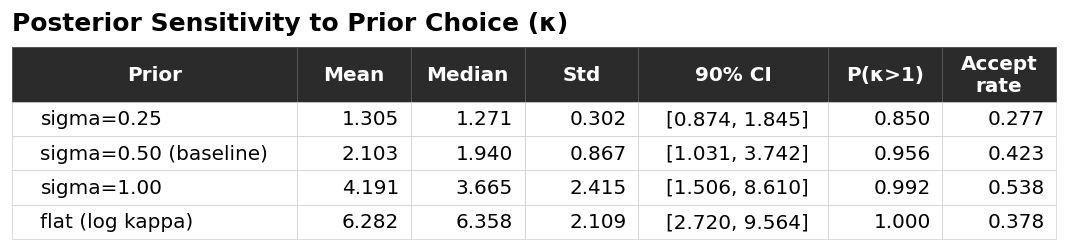

In [23]:
# Prior sensitivity table figure
TBL_FS = 12

col_labels = ['Prior', 'Mean', 'Median', 'Std', '90% CI', 'P(κ>1)', 'Accept\nrate']
col_widths = [0.30, 0.12, 0.12, 0.12, 0.20, 0.12, 0.12]

table_data = []
for _, row in sensitivity_df.iterrows():
    table_data.append([
        row['Prior'],
        f"{row['Mean']:.3f}",
        f"{row['Median']:.3f}",
        f"{row['Std']:.3f}",
        f"[{row['90% CI lo']:.3f}, {row['90% CI hi']:.3f}]",
        f"{row['P(kappa>1)']:.3f}",
        f"{row['Accept rate']:.3f}",
    ])

fig_sens, ax_sens = plt.subplots(figsize=(9, 2.2))
ax_sens.axis('off')

tbl = ax_sens.table(
    cellText=table_data,
    colLabels=col_labels,
    colWidths=col_widths,
    cellLoc='center',
    loc='center',
    bbox=[0.0, 0.0, 1.0, 1.0],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(TBL_FS)

n_cols = len(col_labels)
n_rows = len(table_data)

for j in range(n_cols):
    cell = tbl[0, j]
    cell.set_facecolor('#2B2B2B')
    cell.set_text_props(color='white', fontweight='bold', fontsize=TBL_FS)
    cell.set_edgecolor('#555555')
    cell.set_linewidth(0.6)
    cell.set_height(cell.get_height() * 1.6)

for i in range(n_rows):
    for j in range(n_cols):
        cell = tbl[i + 1, j]
        cell.set_facecolor('#FFFFFF')
        cell.set_edgecolor('#CCCCCC')
        cell.set_linewidth(0.4)
        cell.set_text_props(fontsize=TBL_FS)
        if j >= 1:
            cell.set_text_props(ha='right', fontsize=TBL_FS)
    tbl[i + 1, 0].set_text_props(ha='left', fontsize=TBL_FS)

ax_sens.set_title(
    'Posterior Sensitivity to Prior Choice (κ)',
    fontsize=TBL_FS + 3, fontweight='bold', pad=10, loc='left'
)

fig_sens.tight_layout()
fig_sens.savefig('figureD_prior_sensitivity_table.png', bbox_inches='tight', dpi=300)
plt.show()

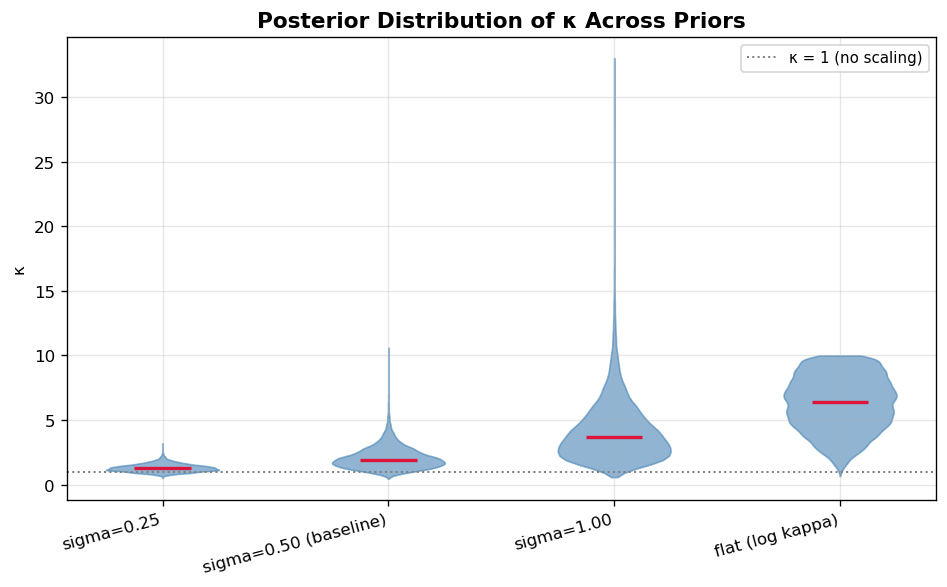

In [24]:
# Plot 1: violin -- distribution of kappa as a function of the prior
fig, ax = plt.subplots(figsize=(8, 5))
labels          = [lbl for lbl, _ in prior_settings]
data_for_violin = [sensitivity[lbl]["posterior"] for lbl in labels]

parts = ax.violinplot(data_for_violin, showmedians=True, showextrema=False)
for pc in parts["bodies"]:
    pc.set_facecolor("steelblue")
    pc.set_alpha(0.6)
    pc.set_edgecolor("steelblue")
parts["cmedians"].set_color("crimson")
parts["cmedians"].set_linewidth(2)

ax.axhline(1.0, color="gray", lw=1.2, ls=":", label="κ = 1 (no scaling)")
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("κ")
ax.set_title("Posterior Distribution of κ Across Priors", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

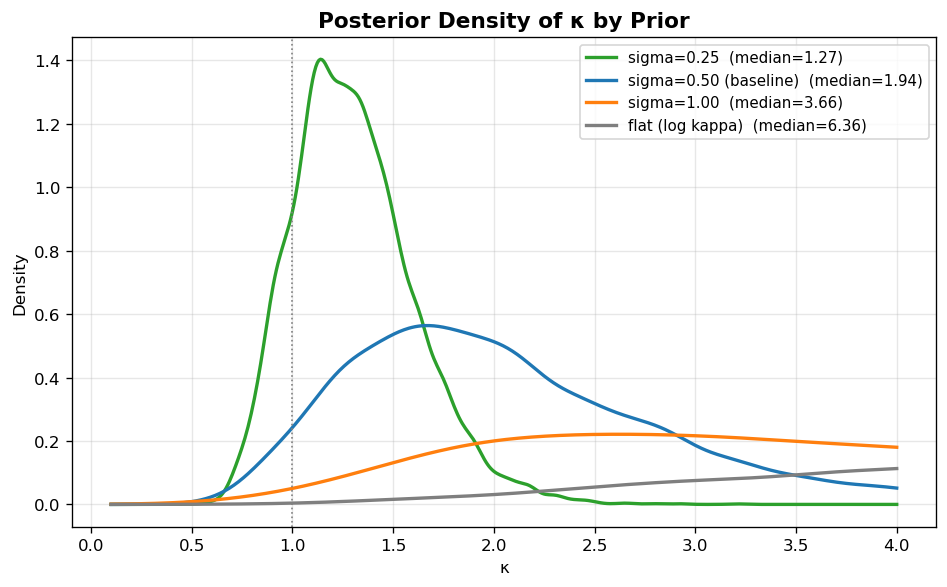

In [25]:
# Plot 2: overlaid posterior densities
from scipy.stats import gaussian_kde as gkde

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2ca02c", "#1f77b4", "#ff7f0e", "#7f7f7f"]
k_grid = np.linspace(0.1, 4.0, 500)

for (label, _), color in zip(prior_settings, colors):
    post_s = sensitivity[label]["posterior"]
    dens   = gkde(post_s)
    ax.plot(k_grid, dens(k_grid), color=color, lw=2,
            label=f"{label}  (median={np.median(post_s):.2f})")

ax.axvline(1.0, color="gray", lw=1, ls=":")
ax.set_xlabel("κ")
ax.set_ylabel("Density")
ax.set_title("Posterior Density of κ by Prior", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

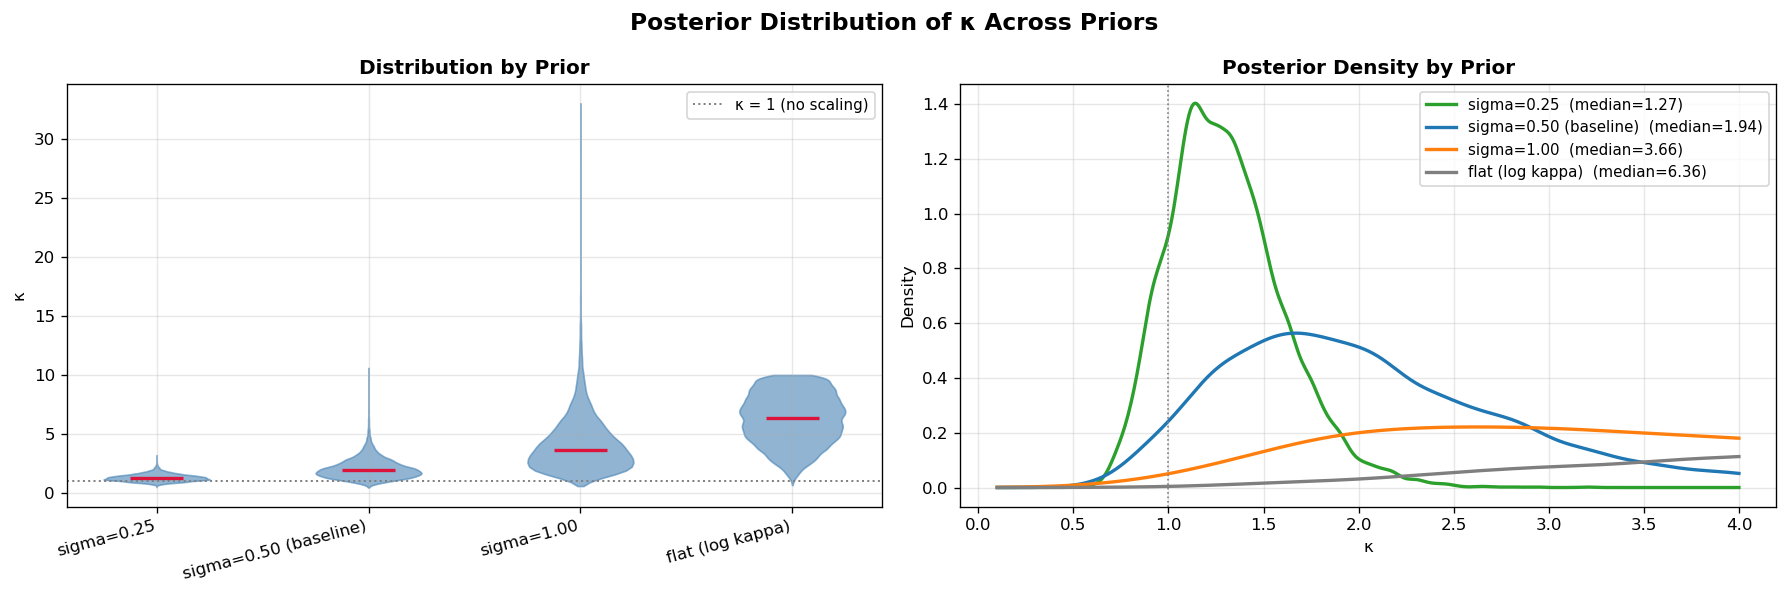

In [26]:
# Plot 3: violin + overlaid posterior densities, combined
from scipy.stats import gaussian_kde as gkde

fig, (ax_violin, ax_dens) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Posterior Distribution of κ Across Priors', fontsize=14, fontweight='bold')

# Left: violin plot
labels          = [lbl for lbl, _ in prior_settings]
data_for_violin = [sensitivity[lbl]["posterior"] for lbl in labels]

parts = ax_violin.violinplot(data_for_violin, showmedians=True, showextrema=False)
for pc in parts["bodies"]:
    pc.set_facecolor("steelblue")
    pc.set_alpha(0.6)
    pc.set_edgecolor("steelblue")
parts["cmedians"].set_color("crimson")
parts["cmedians"].set_linewidth(2)

ax_violin.axhline(1.0, color="gray", lw=1.2, ls=":", label="κ = 1 (no scaling)")
ax_violin.set_xticks(range(1, len(labels) + 1))
ax_violin.set_xticklabels(labels, rotation=15, ha="right")
ax_violin.set_ylabel("κ")
ax_violin.set_title("Distribution by Prior", fontsize=12, fontweight="bold")
ax_violin.legend(fontsize=9)

# Right: overlaid posterior densities
colors = ["#2ca02c", "#1f77b4", "#ff7f0e", "#7f7f7f"]
k_grid = np.linspace(0.1, 4.0, 500)

for (label, _), color in zip(prior_settings, colors):
    post_s = sensitivity[label]["posterior"]
    dens   = gkde(post_s)
    ax_dens.plot(k_grid, dens(k_grid), color=color, lw=2,
                 label=f"{label}  (median={np.median(post_s):.2f})")

ax_dens.axvline(1.0, color="gray", lw=1, ls=":")
ax_dens.set_xlabel("κ")
ax_dens.set_ylabel("Density")
ax_dens.set_title("Posterior Density by Prior", fontsize=12, fontweight="bold")
ax_dens.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 8. Rescaling the EP Curve by the Calibrated Scaling Factor

Take a point estimate of $\kappa$ from the Section 6 baseline posterior (median and
mean) and rescale the OEP curve vertically,

$$\text{loss}_\kappa(\text{RP}) = \kappa \cdot \text{loss}_{1}(\text{RP}).$$

A fixed historical loss $L$ then lands at a shorter return period,
$\text{RP}_\kappa(L) = \text{RP}_{1}(L / \kappa)$ -- obtained by inverting the empirical
OEP curve at $L / \kappa$. Same YLT, same inversion, same event set.

In [27]:
# Rescale the EP curve by the calibrated kappa (base case, sigma = 0.5)
# Point estimates from the Section 6 baseline posterior (LogNormal(0, 0.5) prior).
kappa_med    = float(np.median(posterior_kappa))
kappa_mean   = float(posterior_kappa.mean())
_k_lo, _k_hi = np.percentile(posterior_kappa, [5, 95])

print("Calibrated scaling factor kappa  (base case, LogNormal(0, 0.5) prior)")
print(f"  posterior median  : {kappa_med:.3f}")
print(f"  posterior mean    : {kappa_mean:.3f}")
print(f"  90% credible int. : [{_k_lo:.3f}, {_k_hi:.3f}]")
print()

# Rescaled EP curve:  loss_kappa(RP) = kappa * loss_1(RP)
#   => a fixed historical loss L maps to  RP_kappa(L) = RP_1(L / kappa)
#   (invert the same empirical OEP curve used in Section 3, evaluated at L / kappa)
def scaled_return_period(loss_value, kappa):
    return np.interp(np.asarray(loss_value, dtype=float) / kappa,
                     _loss_emp[::-1], _rp_emp[::-1])

appc = df_events[['Year', 'Event', 'NormalizedLoss', 'ReturnPeriod']].copy()
appc.columns = ['Year', 'Event', 'NormalizedLoss', 'RP_kappa1']
appc['RP_kappa_median'] = scaled_return_period(appc['NormalizedLoss'].values, kappa_med)
appc['RP_kappa_mean']   = scaled_return_period(appc['NormalizedLoss'].values, kappa_mean)
appc['RP_compression']  = appc['RP_kappa1'] / appc['RP_kappa_median']

appc_sorted = appc.sort_values('RP_kappa1', ascending=False).reset_index(drop=True)
print(appc_sorted.to_string(index=False, float_format=lambda x: f'{x:,.1f}'))
print()
_sandy = appc.loc[appc.Event == 'Sandy'].iloc[0]
print(f"Return-period compression (kappa = 1  ->  kappa = {kappa_med:.2f} median):")
print(f"  mean factor : x{appc['RP_compression'].mean():.2f}")
print(f"  range       : x{appc['RP_compression'].min():.2f}  to  x{appc['RP_compression'].max():.2f}")
print(f"  Sandy       : {_sandy.RP_kappa1:.0f}-yr  ->  {_sandy.RP_kappa_median:.0f}-yr")
appc_sorted

Calibrated scaling factor kappa  (base case, LogNormal(0, 0.5) prior)
  posterior median  : 1.940
  posterior mean    : 2.103
  90% credible int. : [1.031, 3.742]

 Year    Event  NormalizedLoss  RP_kappa1  RP_kappa_median  RP_kappa_mean  RP_compression
 2012    Sandy       597851946       54.7             22.1           20.2             2.5
 2017     Irma       329094818       24.1             11.7           10.9             2.1
 2005    Wilma       187077855       12.9              7.4            7.0             1.7
 2011    Irene       184439930       12.7              7.3            7.0             1.7
 2005  Katrina       131442372        9.4              5.9            5.6             1.6
 2022      Ian       130751756        9.4              5.8            5.6             1.6
 2021      Ida       112657154        8.3              5.4            5.1             1.6
 2017   Harvey       109219352        8.1              5.3            5.0             1.5
 2024   Helene       10867

,Year,Event,NormalizedLoss,RP_kappa1,RP_kappa_median,RP_kappa_mean,RP_compression
0,2012,Sandy,597851946,54.737986,22.118269,20.159952,2.474786
1,2017,Irma,329094818,24.140835,11.734035,10.913053,2.057334
2,2005,Wilma,187077855,12.923267,7.410745,7.018690,1.743855
3,2011,Irene,184439930,12.733575,7.333388,6.962028,1.736384
4,2005,Katrina,131442372,9.406521,5.860468,5.589900,1.605080
5,2022,Ian,130751756,9.368651,5.841592,5.573513,1.603784
6,2021,Ida,112657154,8.301700,5.355927,5.117487,1.550003
7,2017,Harvey,109219352,8.122926,5.262389,5.031431,1.543582
8,2024,Helene,108679964,8.082436,5.249359,5.017765,1.539699
9,2004,Jeanne,44694262,4.641872,3.384019,3.272531,1.371704


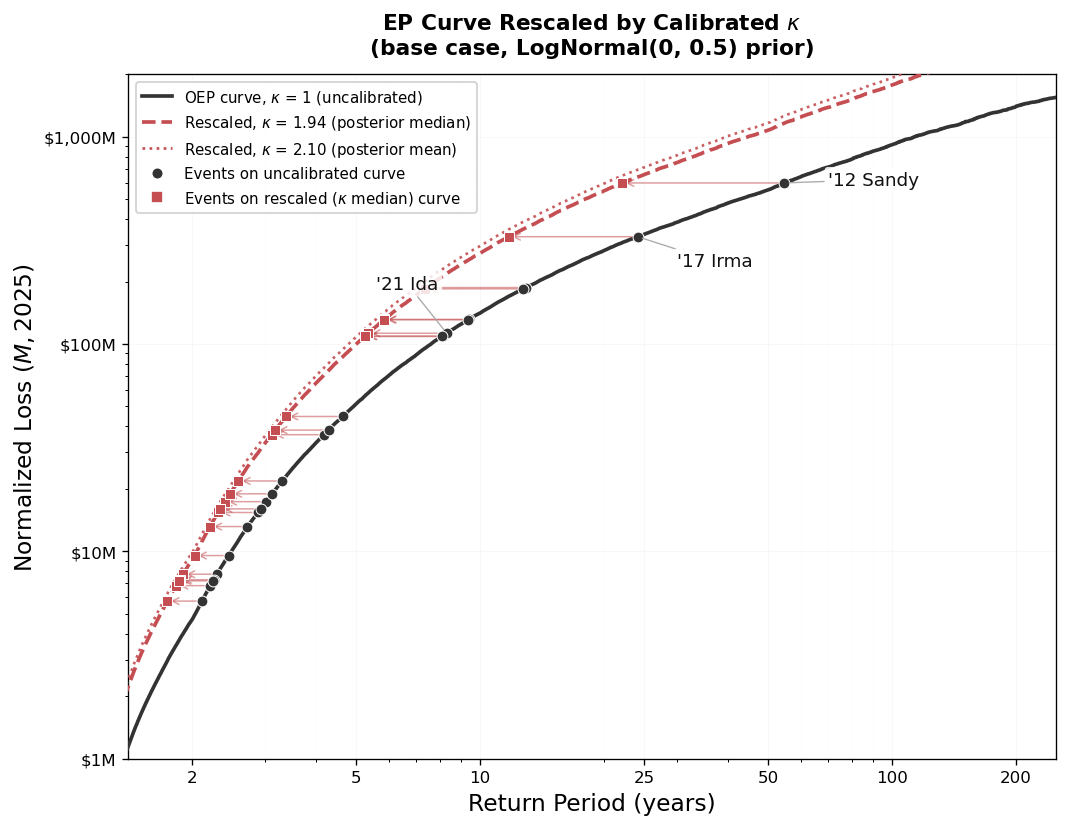

In [28]:
# EP curve rescaled by the calibrated kappa
_pm        = (_rp_emp >= 1.3) & (_rp_emp <= 300)
rp_curve   = _rp_emp[_pm]
loss_curve = _loss_emp[_pm]

fig_c, ax = plt.subplots(figsize=(9, 7))

ax.loglog(rp_curve, loss_curve / 1e6, '-', color='#333333', lw=2.2, zorder=3)
ax.loglog(rp_curve, kappa_med  * loss_curve / 1e6, '--', color='#C44E52', lw=2.2, zorder=3)
ax.loglog(rp_curve, kappa_mean * loss_curve / 1e6, ':',  color='#C44E52', lw=1.6, zorder=3, alpha=0.9)

ax.loglog(appc['RP_kappa1'],       appc['NormalizedLoss'] / 1e6, 'o', color='#333333',
          ms=6.5, zorder=5, markeredgecolor='white', markeredgewidth=0.6)
ax.loglog(appc['RP_kappa_median'], appc['NormalizedLoss'] / 1e6, 's', color='#C44E52',
          ms=6.5, zorder=6, markeredgecolor='white', markeredgewidth=0.6)

# arrows: each event shifts left to a shorter return period on the calibrated curve
for _, r in appc.iterrows():
    y = r.NormalizedLoss / 1e6
    ax.annotate('', xy=(r.RP_kappa_median, y), xytext=(r.RP_kappa1, y),
                arrowprops=dict(arrowstyle='->', color='#C44E52', lw=0.9, alpha=0.55), zorder=4)

for ev, (xt, yt, ha) in {'Sandy': (70, 620, 'left'),
                         'Irma':  (30, 250, 'left'),
                         'Ida':   (5.6, 195, 'left')}.items():
    r = appc.loc[appc.Event == ev].iloc[0]
    ax.annotate(f"'{str(int(r.Year))[-2:]} {ev}", xy=(r.RP_kappa1, r.NormalizedLoss / 1e6),
                xytext=(xt, yt), fontsize=11, color='#111111', ha=ha, va='center', zorder=7,
                arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.8, shrinkA=0, shrinkB=3),
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.85))

handles = [
    Line2D([0], [0], color='#333333', lw=2.2, label=r'OEP curve, $\kappa$ = 1 (uncalibrated)'),
    Line2D([0], [0], color='#C44E52', lw=2.2, ls='--',
           label=rf'Rescaled, $\kappa$ = {kappa_med:.2f} (posterior median)'),
    Line2D([0], [0], color='#C44E52', lw=1.6, ls=':',
           label=rf'Rescaled, $\kappa$ = {kappa_mean:.2f} (posterior mean)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#333333', ms=7,
           label='Events on uncalibrated curve'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#C44E52', ms=7,
           label=r'Events on rescaled ($\kappa$ median) curve'),
]
ax.legend(handles=handles, fontsize=9, loc='upper left', framealpha=0.92, edgecolor='#cccccc')

ax.set_xlabel('Return Period (years)', fontsize=14)
ax.set_ylabel('Normalized Loss ($M, 2025$)', fontsize=14)
ax.set_title('EP Curve Rescaled by Calibrated $\\kappa$\n'
             '(base case, LogNormal(0, 0.5) prior)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim([1.4, 250]); ax.set_ylim([1, 2000])
ax.set_xticks([2, 5, 10, 25, 50, 100, 200])
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
ax.yaxis.set_minor_locator(mticker.LogLocator(subs='all', numticks=10))
ax.grid(True, which='major', lw=0.4, color='#dddddd')
ax.grid(True, which='minor', lw=0.2, color='#eeeeee')

fig_c.tight_layout()
fig_c.savefig('figureC_ep_rescaled.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [29]:
# Recompute Section 5's chunk-percentile check with the calibrated kappa.
# Reuses chunk_losses (Section 5, kappa=1 draws) and kappa_med / kappa_mean.
# Scaling commutes with the draw, so kappa * chunk_losses is the kappa-scaled
# model's chunk distribution -- no need to resimulate.
def chunk_percentile_summary(scale, label):
    ca_AAL = (chunk_losses * scale).mean(axis=1)
    ca_sum = (chunk_losses * scale).sum(axis=1)
    ca_max = (chunk_losses * scale).max(axis=1)

    pe_AAL = 100 * (ca_AAL >= obs_AAL).mean()
    pe_sum = 100 * (ca_sum >= obs_sum).mean()
    pe_max = 100 * (ca_max >= obs_max).mean()

    pr_AAL = 100 * (ca_AAL < obs_AAL).mean()
    pr_sum = 100 * (ca_sum < obs_sum).mean()
    pr_max = 100 * (ca_max < obs_max).mean()

    print(f"\n-- {label} (kappa = {scale:.3f}) --")
    print(f"{'Metric':<25} {'Observed':>12} {'Percentile':>12} {'% Exceeding':>14} {'1-in-N':>10}")
    print("-" * 75)
    for lbl, obs, pe, pr in [
        ('AAL (mean annual)', obs_AAL, pe_AAL, pr_AAL),
        ('Cumulative 21-yr',  obs_sum, pe_sum, pr_sum),
        ('Worst single year', obs_max, pe_max, pr_max),
    ]:
        oneinn = f"1-in-{100/pe:>5.0f}" if pe > 0 else "1-in->1M"
        print(f"{lbl:<25} ${obs/1e6:>10.0f}M {pr:>11.0f}th {pe:>13.1f}%  {oneinn}")

chunk_percentile_summary(1.0,        "kappa = 1 (uncalibrated, original Section 5)")
chunk_percentile_summary(kappa_med,  "kappa = posterior median")
chunk_percentile_summary(kappa_mean, "kappa = posterior mean")


-- kappa = 1 (uncalibrated, original Section 5) (kappa = 1.000) --
Metric                        Observed   Percentile    % Exceeding     1-in-N
---------------------------------------------------------------------------
AAL (mean annual)         $       103M          86th          13.5%  1-in-    7
Cumulative 21-yr          $      2158M          86th          13.5%  1-in-    7
Worst single year         $       598M          68th          32.1%  1-in-    3

-- kappa = posterior median (kappa = 1.940) --
Metric                        Observed   Percentile    % Exceeding     1-in-N
---------------------------------------------------------------------------
AAL (mean annual)         $       103M          56th          43.8%  1-in-    2
Cumulative 21-yr          $      2158M          56th          43.8%  1-in-    2
Worst single year         $       598M          38th          62.1%  1-in-    2

-- kappa = posterior mean (kappa = 2.103) --
Metric                        Observed   Percentil

           Metric        Kappa  Kappa value  Observed ($M)  Percentile  % Exceeding  1-in-N
AAL (mean annual)      kappa=1        1.000        102.759      86.494       13.506   7.404
 Cumulative 21-yr      kappa=1        1.000       2157.947      86.494       13.506   7.404
Worst single year      kappa=1        1.000        597.852      67.917       32.083   3.117
AAL (mean annual) kappa=median        1.940        102.759      56.161       43.839   2.281
 Cumulative 21-yr kappa=median        1.940       2157.947      56.161       43.839   2.281
Worst single year kappa=median        1.940        597.852      37.889       62.111   1.610
AAL (mean annual)   kappa=mean        2.103        102.759      51.442       48.558   2.059
 Cumulative 21-yr   kappa=mean        2.103       2157.947      51.442       48.558   2.059
Worst single year   kappa=mean        2.103        597.852      34.400       65.600   1.524

Kappa              kappa=1  kappa=median  kappa=mean
Metric                    

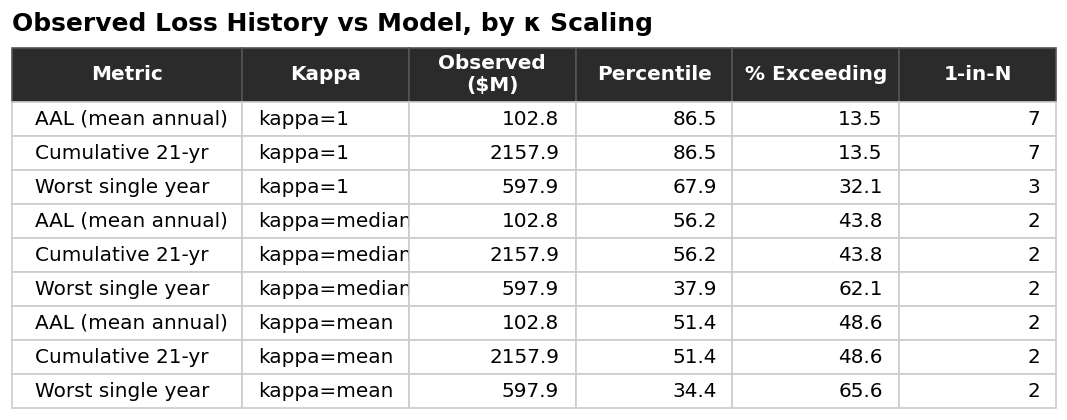

In [30]:
# Comparison table: AAL, cumulative loss, worst single year across kappa scenarios
rows = []
scale_specs = [(1.0, 'kappa=1'), (kappa_med, 'kappa=median'), (kappa_mean, 'kappa=mean')]
metric_specs = [
    ('AAL (mean annual)', lambda s: (chunk_losses * s).mean(axis=1), obs_AAL),
    ('Cumulative 21-yr',  lambda s: (chunk_losses * s).sum(axis=1),  obs_sum),
    ('Worst single year', lambda s: (chunk_losses * s).max(axis=1),  obs_max),
]

for scale, scale_label in scale_specs:
    for metric_label, stat_fn, obs in metric_specs:
        vals = stat_fn(scale)
        pe   = 100 * (vals >= obs).mean()
        pr   = 100 * (vals < obs).mean()
        rows.append({
            'Metric':       metric_label,
            'Kappa':        scale_label,
            'Kappa value':  scale,
            'Observed ($M)': obs / 1e6,
            'Percentile':   pr,
            '% Exceeding':  pe,
            '1-in-N':       (100 / pe) if pe > 0 else np.nan,
        })

comparison_df = pd.DataFrame(rows)

# Long format (one row per metric x kappa) -- full detail
print(comparison_df.round(3).to_string(index=False))

print()

# Wide format -- percentile side-by-side per metric, quick-glance comparison
comparison_wide = comparison_df.pivot(index='Metric', columns='Kappa', values='Percentile')
comparison_wide = comparison_wide[[s[1] for s in scale_specs]]  # preserve kappa=1/median/mean order
print(comparison_wide.round(3).to_string())


# Table figure version
TBL_FS = 12
col_labels = ['Metric', 'Kappa', 'Observed\n($M)', 'Percentile', '% Exceeding', '1-in-N']
col_widths = [0.22, 0.16, 0.16, 0.15, 0.16, 0.15]

table_data = [
    [r['Metric'], r['Kappa'], f"{r['Observed ($M)']:.1f}", f"{r['Percentile']:.1f}",
     f"{r['% Exceeding']:.1f}", f"{r['1-in-N']:.0f}" if not np.isnan(r['1-in-N']) else "n/a"]
    for r in comparison_df.to_dict('records')
]

fig_cmp, ax_cmp = plt.subplots(figsize=(9, 3.6))
ax_cmp.axis('off')

tbl = ax_cmp.table(cellText=table_data, colLabels=col_labels, colWidths=col_widths,
                    cellLoc='center', loc='center', bbox=[0.0, 0.0, 1.0, 1.0])
tbl.auto_set_font_size(False)
tbl.set_fontsize(TBL_FS)

for j in range(len(col_labels)):
    cell = tbl[0, j]
    cell.set_facecolor('#2B2B2B')
    cell.set_text_props(color='white', fontweight='bold', fontsize=TBL_FS)
    cell.set_edgecolor('#555555')
    cell.set_height(cell.get_height() * 1.6)

for i in range(len(table_data)):
    for j in range(len(col_labels)):
        cell = tbl[i + 1, j]
        cell.set_facecolor('#FFFFFF')
        cell.set_edgecolor('#CCCCCC')
        cell.set_text_props(fontsize=TBL_FS, ha='right' if j >= 2 else 'left')

ax_cmp.set_title('Observed Loss History vs Model, by κ Scaling', fontsize=TBL_FS + 3,
                  fontweight='bold', pad=10, loc='left')
fig_cmp.tight_layout()
fig_cmp.savefig('figureE_kappa_comparison_table.png', bbox_inches='tight', dpi=300)
plt.show()

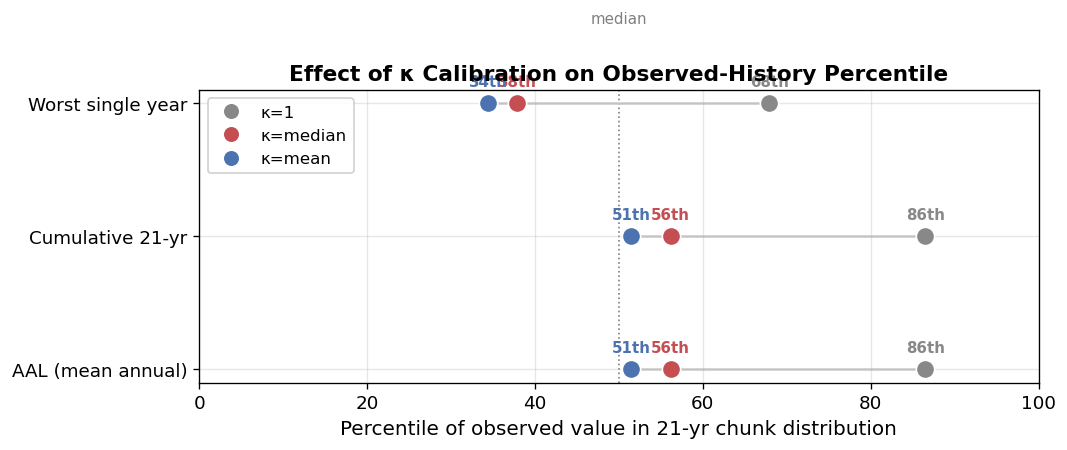

In [31]:
fig, ax = plt.subplots(figsize=(9, 4))

metrics = [
    ('AAL (mean annual)', lambda s: (chunk_losses * s).mean(axis=1), obs_AAL),
    ('Cumulative 21-yr',  lambda s: (chunk_losses * s).sum(axis=1),  obs_sum),
    ('Worst single year', lambda s: (chunk_losses * s).max(axis=1),  obs_max),
]
scales = [(1.0, 'κ=1', '#888888'), (kappa_med, 'κ=median', '#C44E52'), (kappa_mean, 'κ=mean', '#4C72B0')]

for i, (label, stat_fn, obs) in enumerate(metrics):
    pcts = [100 * (stat_fn(s) < obs).mean() for s, _, _ in scales]
    ax.plot(pcts, [i]*len(pcts), '-', color='#cccccc', lw=1.5, zorder=1)
    for (s, slabel, color), p in zip(scales, pcts):
        ax.plot(p, i, 'o', color=color, ms=11, zorder=3, markeredgecolor='white', markeredgewidth=1)
        ax.annotate(f'{p:.0f}th', (p, i), xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=9, color=color, fontweight='bold')

ax.axvline(50, color='gray', lw=1, ls=':', zorder=0)
ax.text(50, len(metrics) - 0.4, 'median', ha='center', fontsize=9, color='gray')
ax.set_yticks(range(len(metrics)))
ax.set_yticklabels([m[0] for m in metrics], fontsize=12)
ax.set_xlim(0, 100)
ax.set_xlabel('Percentile of observed value in 21-yr chunk distribution', fontsize=12)
ax.set_title('Effect of κ Calibration on Observed-History Percentile', fontsize=13, fontweight='bold')
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, ms=10, label=l)
           for _, l, c in scales]
ax.legend(handles=handles, fontsize=10, loc='upper left', framealpha=0.9)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

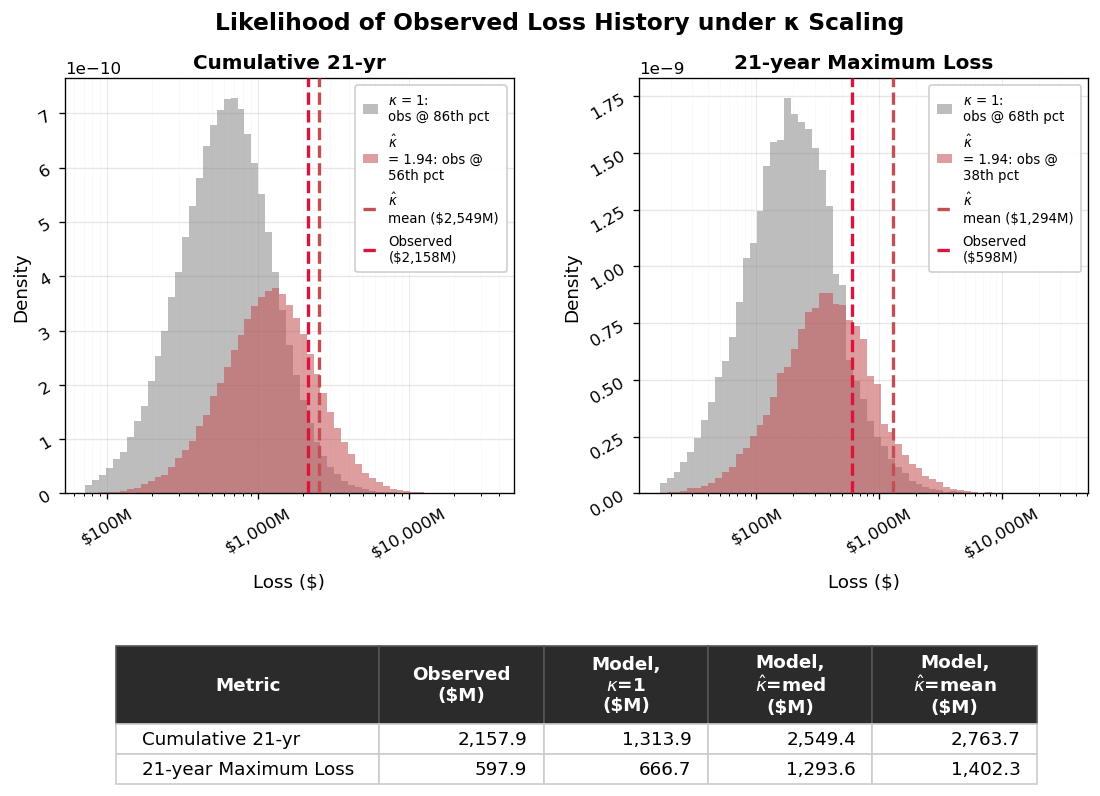

In [39]:
import textwrap

fig = plt.figure(figsize=(11, 7))
gs  = fig.add_gridspec(2, 2, height_ratios=[3, 1.0], hspace=0.55, wspace=0.28,
                       top=0.90, bottom=0.06)
fig.suptitle('Likelihood of Observed Loss History under κ Scaling', fontsize=14, fontweight='bold')

axes = [fig.add_subplot(gs[0, i]) for i in range(2)]

panels = [
    ('Cumulative 21-yr',     lambda s: (chunk_losses * s).sum(axis=1), obs_sum),
    ('21-year Maximum Loss', lambda s: (chunk_losses * s).max(axis=1), obs_max),
]
scale_specs = [
    (1.0,       r'$\kappa$ = 1',                        '#888888', 0.55),
    (kappa_med, rf'$\hat{{\kappa}}$ = {kappa_med:.2f}', '#C44E52', 0.55),
]

def _wrap(s, width=15):
    return '\n'.join(textwrap.wrap(s, width=width))

for ax, (title, stat_fn, obs) in zip(axes, panels):
    vals_by_scale = [(stat_fn(s), slabel, color, alpha) for s, slabel, color, alpha in scale_specs]

    all_vals = np.concatenate([v for v, *_ in vals_by_scale] + [[obs]])
    lo, hi   = np.percentile(all_vals[all_vals > 0], [0.01, 99.99])
    bins     = np.logspace(np.log10(max(lo, 1)), np.log10(hi), 60)

    for vals, slabel, color, alpha in vals_by_scale:
        pct = 100 * (vals < obs).mean()
        ax.hist(np.maximum(vals, 1), bins=bins, density=True, color=color,
                alpha=alpha, edgecolor='none',
                label=_wrap(f'{slabel}: obs @ {pct:.0f}th pct'))

    med_mean = stat_fn(kappa_med).mean()
    ax.axvline(med_mean, color='#C44E52', lw=2, ls='--', zorder=6,
               label=_wrap(rf'$\hat{{\kappa}}$ mean (${med_mean/1e6:,.0f}M)'))
    ax.axvline(obs, color='crimson', lw=2, ls='--', zorder=5,
               label=_wrap(f'Observed (${obs/1e6:,.0f}M)'))

    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:,.0f}M'))
    ax.set_axisbelow(True)
    ax.grid(True, axis='x', which='major', lw=0.6, color='#bbbbbb')
    ax.grid(True, axis='x', which='minor', lw=0.3, color='#dddddd')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Loss ($)', fontsize=11, labelpad=8)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=8, loc='upper right', handlelength=1.1,
              labelspacing=0.7, borderpad=0.6, framealpha=0.92)
    ax.tick_params(labelsize=10, rotation=30)

# ── Table subplot: model point estimate (x kappa) vs observed ──
metric_specs = [
    ('Cumulative 21-yr',     lambda: chunk_losses.sum(axis=1), obs_sum),
    ('21-year Maximum Loss', lambda: chunk_losses.max(axis=1), obs_max),
]
kappa_cols = [(1.0, r'$\kappa$=1'), (kappa_med, r'$\hat{\kappa}$=med'), (kappa_mean, r'$\hat{\kappa}$=mean')]

table_rows = []
for metric_label, stat_fn, obs in metric_specs:
    model_pt = stat_fn().mean()
    row = [metric_label, f"{obs/1e6:,.1f}"]
    for scale, _ in kappa_cols:
        row.append(f"{model_pt * scale / 1e6:,.1f}")
    table_rows.append(row)

col_labels = ['Metric', 'Observed\n($M)'] + [f'Model,\n{lbl}\n($M)' for _, lbl in kappa_cols]
col_widths = [0.24, 0.15, 0.15, 0.15, 0.15]

ax_tbl = fig.add_subplot(gs[1, :])
ax_tbl.axis('off')

tbl = ax_tbl.table(cellText=table_rows, colLabels=col_labels, colWidths=col_widths,
                   cellLoc='center', loc='center', bbox=[0.05, 0.0, 0.9, 1.0])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)

for j in range(len(col_labels)):
    cell = tbl[0, j]
    cell.set_facecolor('#2B2B2B')
    cell.set_text_props(color='white', fontweight='bold', fontsize=11)
    cell.set_edgecolor('#555555')
    cell.set_height(cell.get_height() * 2.6)

for i in range(len(table_rows)):
    for j in range(len(col_labels)):
        cell = tbl[i + 1, j]
        cell.set_facecolor('#FFFFFF')
        cell.set_edgecolor('#CCCCCC')
        cell.set_text_props(fontsize=11, ha='right' if j >= 1 else 'left')

plt.show()
